# Energy Forecasting Project
LSTM vs Linear Regression for next 24h load prediction.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# load data
df = pd.read_csv('AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# scale
scaler = MinMaxScaler()
df['scaled'] = scaler.fit_transform(df['AEP_MW'].values.reshape(-1, 1))

# split
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# windowing function
def make_windows(data, w_in=24, w_out=24):
    X, y = [], []
    vals = data['scaled'].values
    for i in range(len(vals) - w_in - w_out + 1):
        X.append(vals[i : i + w_in])
        y.append(vals[i + w_in : i + w_in + w_out])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_df)
X_test, y_test = make_windows(test_df)

# to torch tensors
train_X_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
train_y_t = torch.tensor(y_train, dtype=torch.float32)
test_X_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)

print("shapes:", train_X_t.shape, train_y_t.shape)

shapes: torch.Size([96971, 24, 1]) torch.Size([96971, 24])


In [2]:
# baseline model (normal equation)
# baseline 1: linear regression using normal equation
X_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
W = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train

X_test_b = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
base_preds = X_test_b @ W

# baseline 2: naive mean baseline (for the flat line on the plot)
multi_baseline_preds = np.tile(np.mean(X_train, axis=1, keepdims=True), (1, 24))
print("baselines calculated successfully.")

baselines calculated successfully.


In [3]:
class GetLastStep(nn.Module):
    def forward(self, x):
        out, _ = x
        return out[:, -1, :]

net = nn.Sequential(
    nn.LSTM(1, 64, num_layers=1, batch_first=True), 
    GetLastStep(),
    nn.Linear(64, 24)
)

loss_fn = nn.MSELoss()
opt = optim.Adam(net.parameters(), lr=0.002) 
print("Model re-configured for faster training.")

Model re-configured for faster training.


In [5]:
from torch.utils.data import DataLoader, TensorDataset

loader = DataLoader(TensorDataset(train_X_t, train_y_t), batch_size=128, shuffle=True)

epochs = 10
net.train()
for ep in range(epochs):
    ep_loss = 0
    for bx, by in loader:
        opt.zero_grad()
        out = net(bx)
        loss = loss_fn(out, by)
        loss.backward()
        opt.step()
        ep_loss += loss.item() * bx.size(0)
        
    print(f"Epoch {ep+1}/{epochs} | Loss: {ep_loss / len(loader.dataset):.6f}")

torch.save(net.state_dict(), 'lstm_model.pth')

Epoch 1/10 | Loss: 0.012293
Epoch 2/10 | Loss: 0.005085
Epoch 3/10 | Loss: 0.004194
Epoch 4/10 | Loss: 0.003995
Epoch 5/10 | Loss: 0.003797
Epoch 6/10 | Loss: 0.003673
Epoch 7/10 | Loss: 0.003527
Epoch 8/10 | Loss: 0.003419
Epoch 9/10 | Loss: 0.003317
Epoch 10/10 | Loss: 0.003230


--- Evaluation Metrics (MW) ---
Linear Regression -> MAE: 716.43 | RMSE: 956.31
PyTorch LSTM      -> MAE: 698.43 | RMSE: 931.18



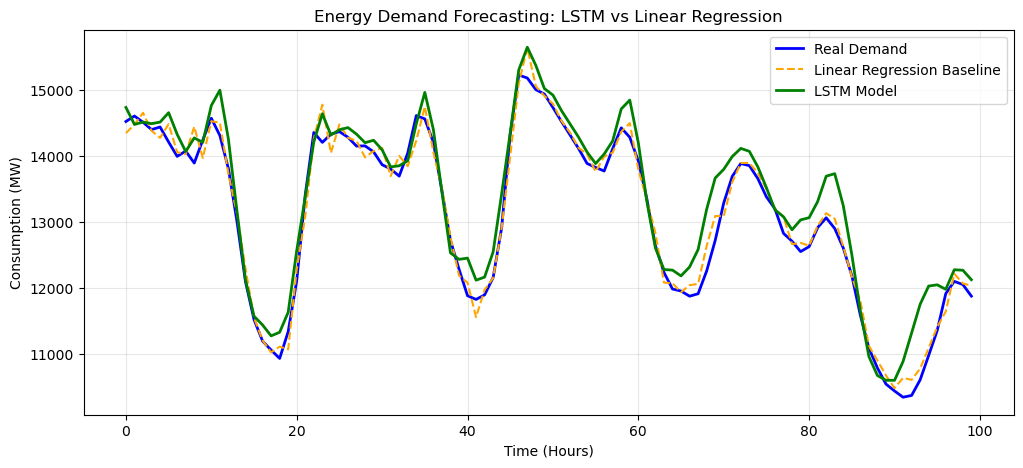

In [12]:
# evaluate and get predictions
net.eval()
with torch.no_grad():
    lstm_out = net(test_X_t).numpy()

# inverse scale to actual megawatt values
y_test_mw = scaler.inverse_transform(y_test)
lstm_mw = scaler.inverse_transform(lstm_out)
base_mw = scaler.inverse_transform(base_preds)

# calculate metrics
mae_lstm = mean_absolute_error(y_test_mw, lstm_mw)
rmse_lstm = np.sqrt(mean_squared_error(y_test_mw, lstm_mw))
mae_base = mean_absolute_error(y_test_mw, base_mw)
rmse_base = np.sqrt(mean_squared_error(y_test_mw, base_mw))

print("--- Evaluation Metrics (MW) ---")
print(f"Linear Regression -> MAE: {mae_base:.2f} | RMSE: {rmse_base:.2f}")
print(f"PyTorch LSTM      -> MAE: {mae_lstm:.2f} | RMSE: {rmse_lstm:.2f}\n")

# plot results (zoom on first 100 hours)
plt.figure(figsize=(12, 5))
plt.plot(y_test_mw[:100, 0], label='Real Demand', color='blue', linewidth=2)
plt.plot(base_mw[:100, 0], label='Linear Regression Baseline', color='orange', linestyle='--', linewidth=1.5)
plt.plot(lstm_mw[:100, 0], label='LSTM Model', color='green', linewidth=2)

plt.title('Energy Demand Forecasting: LSTM vs Linear Regression')
plt.xlabel('Time (Hours)')
plt.ylabel('Consumption (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()